# Extreme Temperatures

1. Caculate Hottest Regions in Hesse
2. Look Closly at the parameters in these regions

In [ ]:
# Import necessary packages

# Geospatial Data Handling
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.features import geometry_mask, shapes
import rasterstats as rs
from pyogrio import read_dataframe
from geocube.api.core import make_geocube
import shapely.geometry as geometry

# Data Handling & Computation
import numpy as np
import pandas as pd
import itertools

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
alt.data_transformers.enable("vegafusion")

In [ ]:
# path to the data (input & output)

# Data not included, as it can be downloaded elsewhere and processed using the provided scripts.
# Data Sources:
# Air Temperature (TA): Obtained from HOSTRADA, German Weather Service.
# Land Surface Temperature (LST): Retrieved from MODIS via Google Earth Engine.

# bath path
path_data = "path/to/data"

# region of interest and urban areas
path_roi = path_data+ "roi/gemeinde_la.shp"
# path_urban = path_data+ "other/urban_v3.tif"

# PET daytime
path_PET = path_data+ "temperature/klimanalyse/PET_1000.tif"
# LST 90th percentile MODIS aqua nighttime
path_LST_DT = path_data+ "temperature/modis/DT/DT_90th_MODIS_aqua_night_2011-1-1_2021-1-1_clip.tif"
# HUMIDEX 90th percentile 01:00
path_HUMIDEX_DT = path_data+ "temperature/hostrada/hourly/DT/90th/DT_tas_1hr_HOSTRADA_h1_90th_25832_clip.tif"
# Ta > 35°C
path_very_hot_day = path_data+ "temperature/hostrada/heatwave/tas_1hr_HOSTRADA_2011_2020_months-678_very_hot_day_25832_clip.tif"
# Ta > 30°C
path_hot_day = path_data+ "temperature/hostrada/heatwave/tas_1hr_HOSTRADA_2011_2020_months-678_hot_day_25832_clip.tif"
# Ta > 28°C and 95th percentile for at least 3 days (number of total days categoriezed as heatwave)
path_heatwave_days = path_data+ "temperature/hostrada/heatwave/tas_1hr_HOSTRADA_2011_2020_months-678_heat_wave_days_95th_28_25832_clip.tif"
# Ta > 28°C and 95th percentile for at least 3 days (number of heatwave events)
path_heatwave_events = path_data+ "temperature/hostrada/heatwave/tas_1hr_HOSTRADA_2011_2020_months-678_heat_wave_events_95th_28_25832_clip.tif"
# ΔT > 0.5°C percentage of diurnal cycle
path_hotspots =  path_data+ "temperature/hostrada/hotspots_clipped.tif"
# ΔT < -0.5°C percentage of diurnal cycle
path_coldspots = path_data+ "temperature/hostrada/coldspots_clipped.tif"
# mean Ta 01:00
path_Ta_DT_mean =  path_data+ "temperature/hostrada/hourly/DT/mean/DT_tas_1hr_HOSTRADA_h1_mean_25832_clip.tif"
# 90th percentile Ta 01:00
path_Ta_DT_90 =  path_data+ "temperature/hostrada/hourly/DT/90th/DT_tas_1hr_HOSTRADA_h1_90th_25832_clip.tif"

# List of raster files
raster_paths = {
    "PET": path_PET,
    "LST_DT": path_LST_DT,
    "HUMIDEX_DT": path_HUMIDEX_DT,
    "Very_Hot_Day": path_very_hot_day,
    "Hot_Day": path_hot_day,
    "Heatwave_Days": path_heatwave_days,
    "Heatwave_Events": path_heatwave_events,
    "Ta_DT": path_Ta_DT_mean,
    "Ta_DT_90th": path_Ta_DT_90,
}

# 1. Hottest Regions

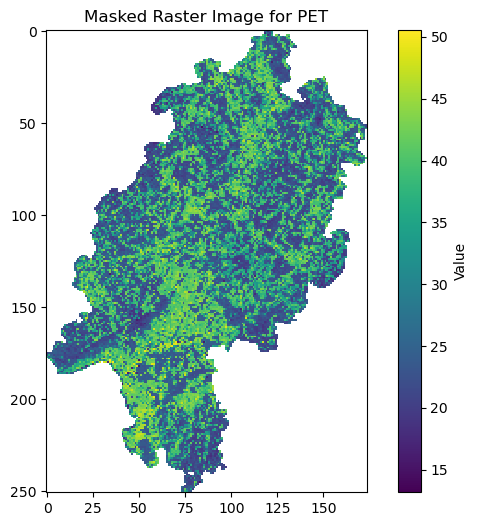

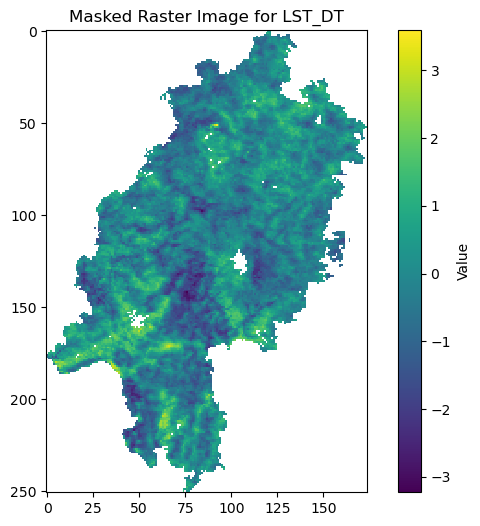

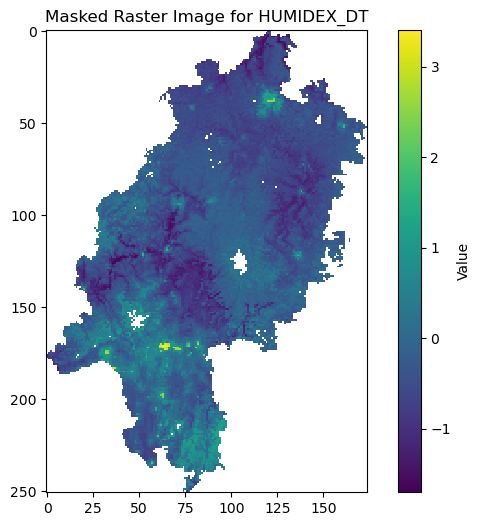

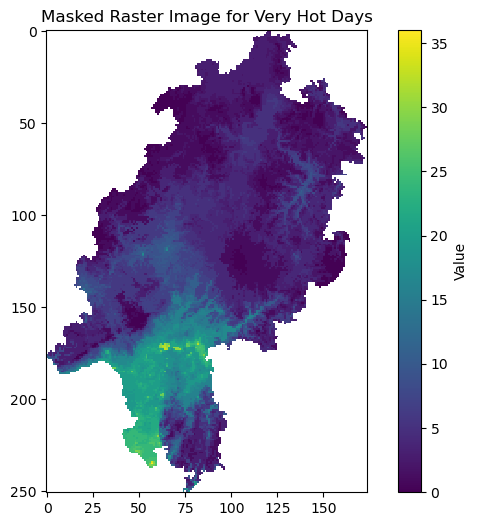

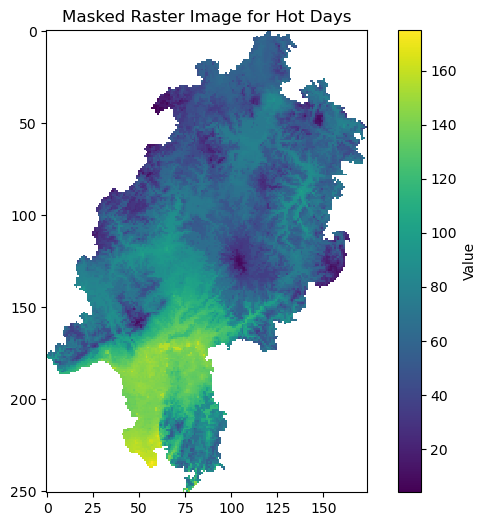

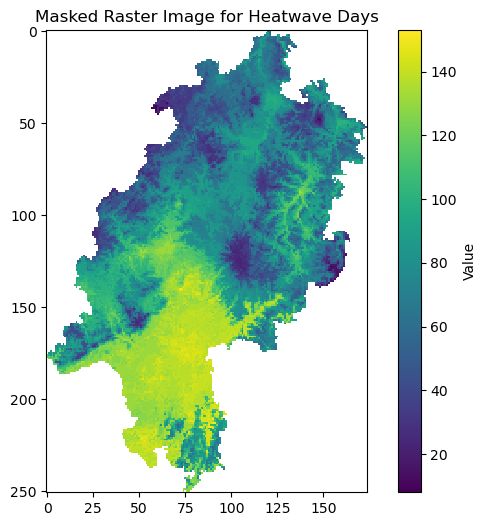

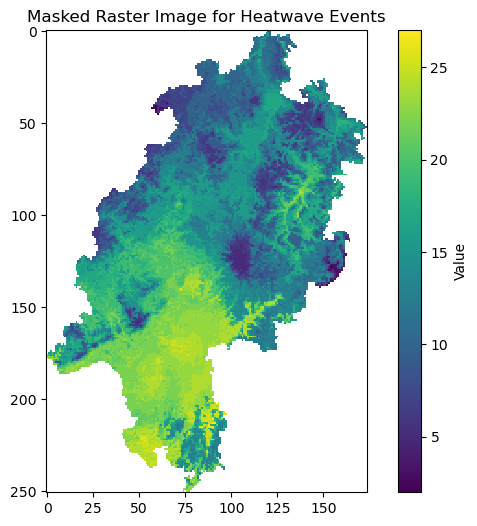

In [ ]:
# Load ROI vector (region of interest)
roi_gdf = gpd.read_file(path_roi)

# Dissolve based on 'kreis_bz'
roi_gdf = roi_gdf.dissolve(by="kreis_bz", as_index=False)

# Function to mask raster with urban areas and compute zonal stats on ROI
def compute_zonal_stats(raster_path, variable):
    with rasterio.open(raster_path) as src:
        # Read raster
        raster_data = src.read(1)
        raster_data = np.where(raster_data == 9999, np.nan, raster_data)  # Set nodata values to NaN

        # Load urban mask
        # with rasterio.open(path_urban) as urban_src:
        #   urban_data = urban_src.read(1)
        #   urban_transform = urban_src.transform
           
        # Apply mask: set all non-urban (i.e., where urban_mask is 0) to NaN
        # masked_image = np.where(urban_data == 1 , raster_data, np.nan)
        masked_image = raster_data

        # Plot the masked image
        plt.figure(figsize=(8, 6))
        plt.imshow(masked_image, cmap="viridis", interpolation="nearest")
        plt.colorbar(label="Value")
        plt.title(f"Masked Raster Image for {variable}")
        plt.show()
                
        # Compute zonal stats using ROI vector
        stats = rs.zonal_stats(
            roi_gdf,  # Use ROI as the analysis unit
            masked_image,  # Use masked raster
            affine=src.transform,
            stats=["min", "max", "mean", "std", "median"],
            nodata=np.nan
        )
    return stats


# Apply zonal stats to each raster
rasters = {
    "PET": path_PET,
    "LST_DT": path_LST_DT,
    "HUMIDEX_DT": path_HUMIDEX_DT,
    "Very Hot Days": path_very_hot_day,
    "Hot Days": path_hot_day,
    "Heatwave Days": path_heatwave_days,
    "Heatwave Events": path_heatwave_events
}

# Initialize df_zonal_stats as an empty DataFrame
df_zonal_stats = pd.DataFrame(columns=["Region", "Variable", "min", "max", "mean", "std", "median", "geometry"])
for variable, raster_path in rasters.items():
    stats = compute_zonal_stats(raster_path, variable)
    temp_df = pd.DataFrame(stats)

    # Add Variable name
    temp_df["Variable"] = variable

    # Ensure region and geometry match correctly
    temp_df["Region"] = roi_gdf["kreis_bz"].values  # Region name "kreis_bz" or "gid" for ID
    temp_df["geometry"] = roi_gdf["geometry"].values  # Geometry

    # Concatenate
    df_zonal_stats = pd.concat([df_zonal_stats, temp_df], ignore_index=True)

df_zonal_stats = df_zonal_stats[["Region", "Variable", "min", "max", "mean", "std", "median", "geometry"]]

# Sort by hottest mean values
df_zonal_stats = df_zonal_stats.sort_values(by=["mean"], ascending=[False])

# Remove rows without geometry
df_zonal_stats = df_zonal_stats[df_zonal_stats["geometry"].notnull()]
# Remove duplicate rows
df_zonal_stats = df_zonal_stats.drop_duplicates()

# Convert DataFrame to GeoDataFrame
gdf_zonal_stats = gpd.GeoDataFrame(df_zonal_stats, geometry="geometry", crs=roi_gdf.crs)

# Save to CSV (optional)
df_zonal_stats.to_csv("./zonal_stats_urban.csv", index=False)

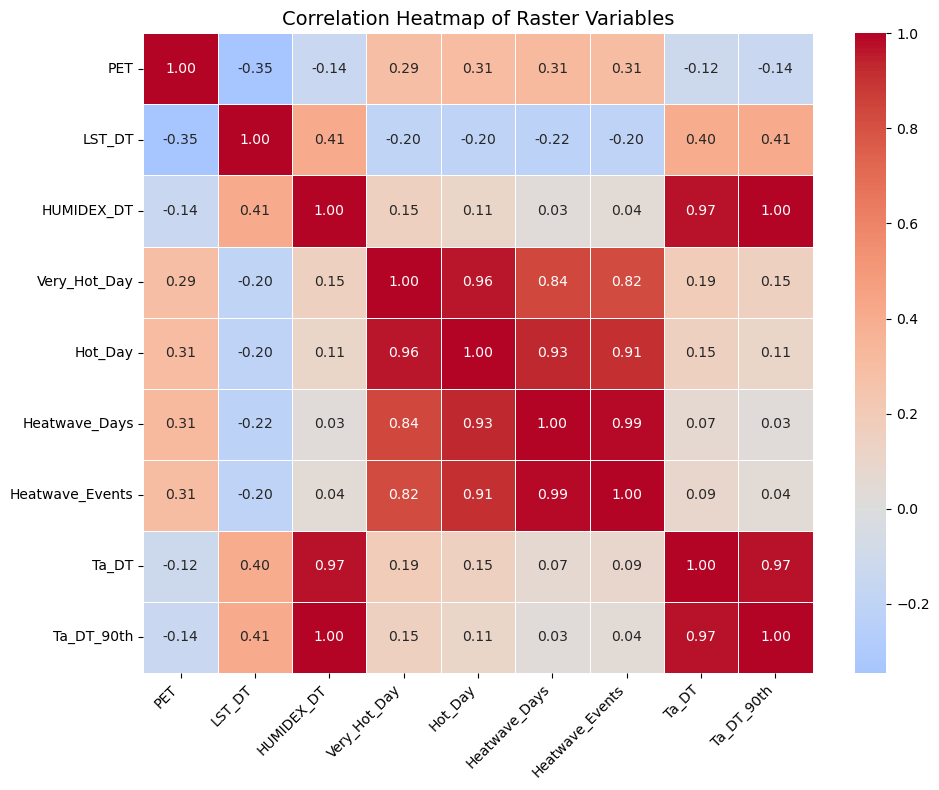

In [5]:
# Function to convert raster data to a DataFrame
def raster_to_dataframe(raster_data, transform, name):
    """Convert raster data to a DataFrame with x, y, and values."""
    height, width = raster_data.shape
    xs, ys, values = [], [], []

    for i in range(height):
        for j in range(width):
            value = raster_data[i, j]
            if not np.isnan(value):  # Exclude NaN values
                x, y = transform * (j, i)  # Convert to spatial coordinates
                xs.append(x)
                ys.append(y)
                values.append(value)

    return pd.DataFrame({"x": xs, "y": ys, name: values})

# Initialize an empty DataFrame to merge raster data
df_final = None

# Iterate over all raster files
for var_name, raster_path in raster_paths.items():
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)  # Read the first band
        raster_data = np.where(raster_data == 9999, np.nan, raster_data)  # Mask invalid values
        transform = src.transform

        # Convert raster to DataFrame
        df_raster = raster_to_dataframe(raster_data, transform, var_name)

        # Merge with final DataFrame
        if df_final is None:
            df_final = df_raster
        else:
            df_final = pd.merge(df_final, df_raster, on=["x", "y"], how="outer")

# Drop rows with NaN values (optional)
df_final = df_final.dropna()

# Compute correlation matrix
corr_matrix = df_final.drop(columns=["x", "y"]).corr()

# Plot correlation heatmap with values
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,  # Display correlation values
    fmt=".2f",  # Format to 2 decimal places
    cmap="coolwarm",  # Color scheme
    center=0,  # Center around zero
    linewidths=0.5,  # Thin grid lines
    cbar=True  # Show color bar
)

# Titles and labels
plt.title("Correlation Heatmap of Raster Variables", fontsize=14)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
df_zonal_stats.columns

In [ ]:
df_zonal_stats[df_zonal_stats["Variable"]=="Heatwave Events"]

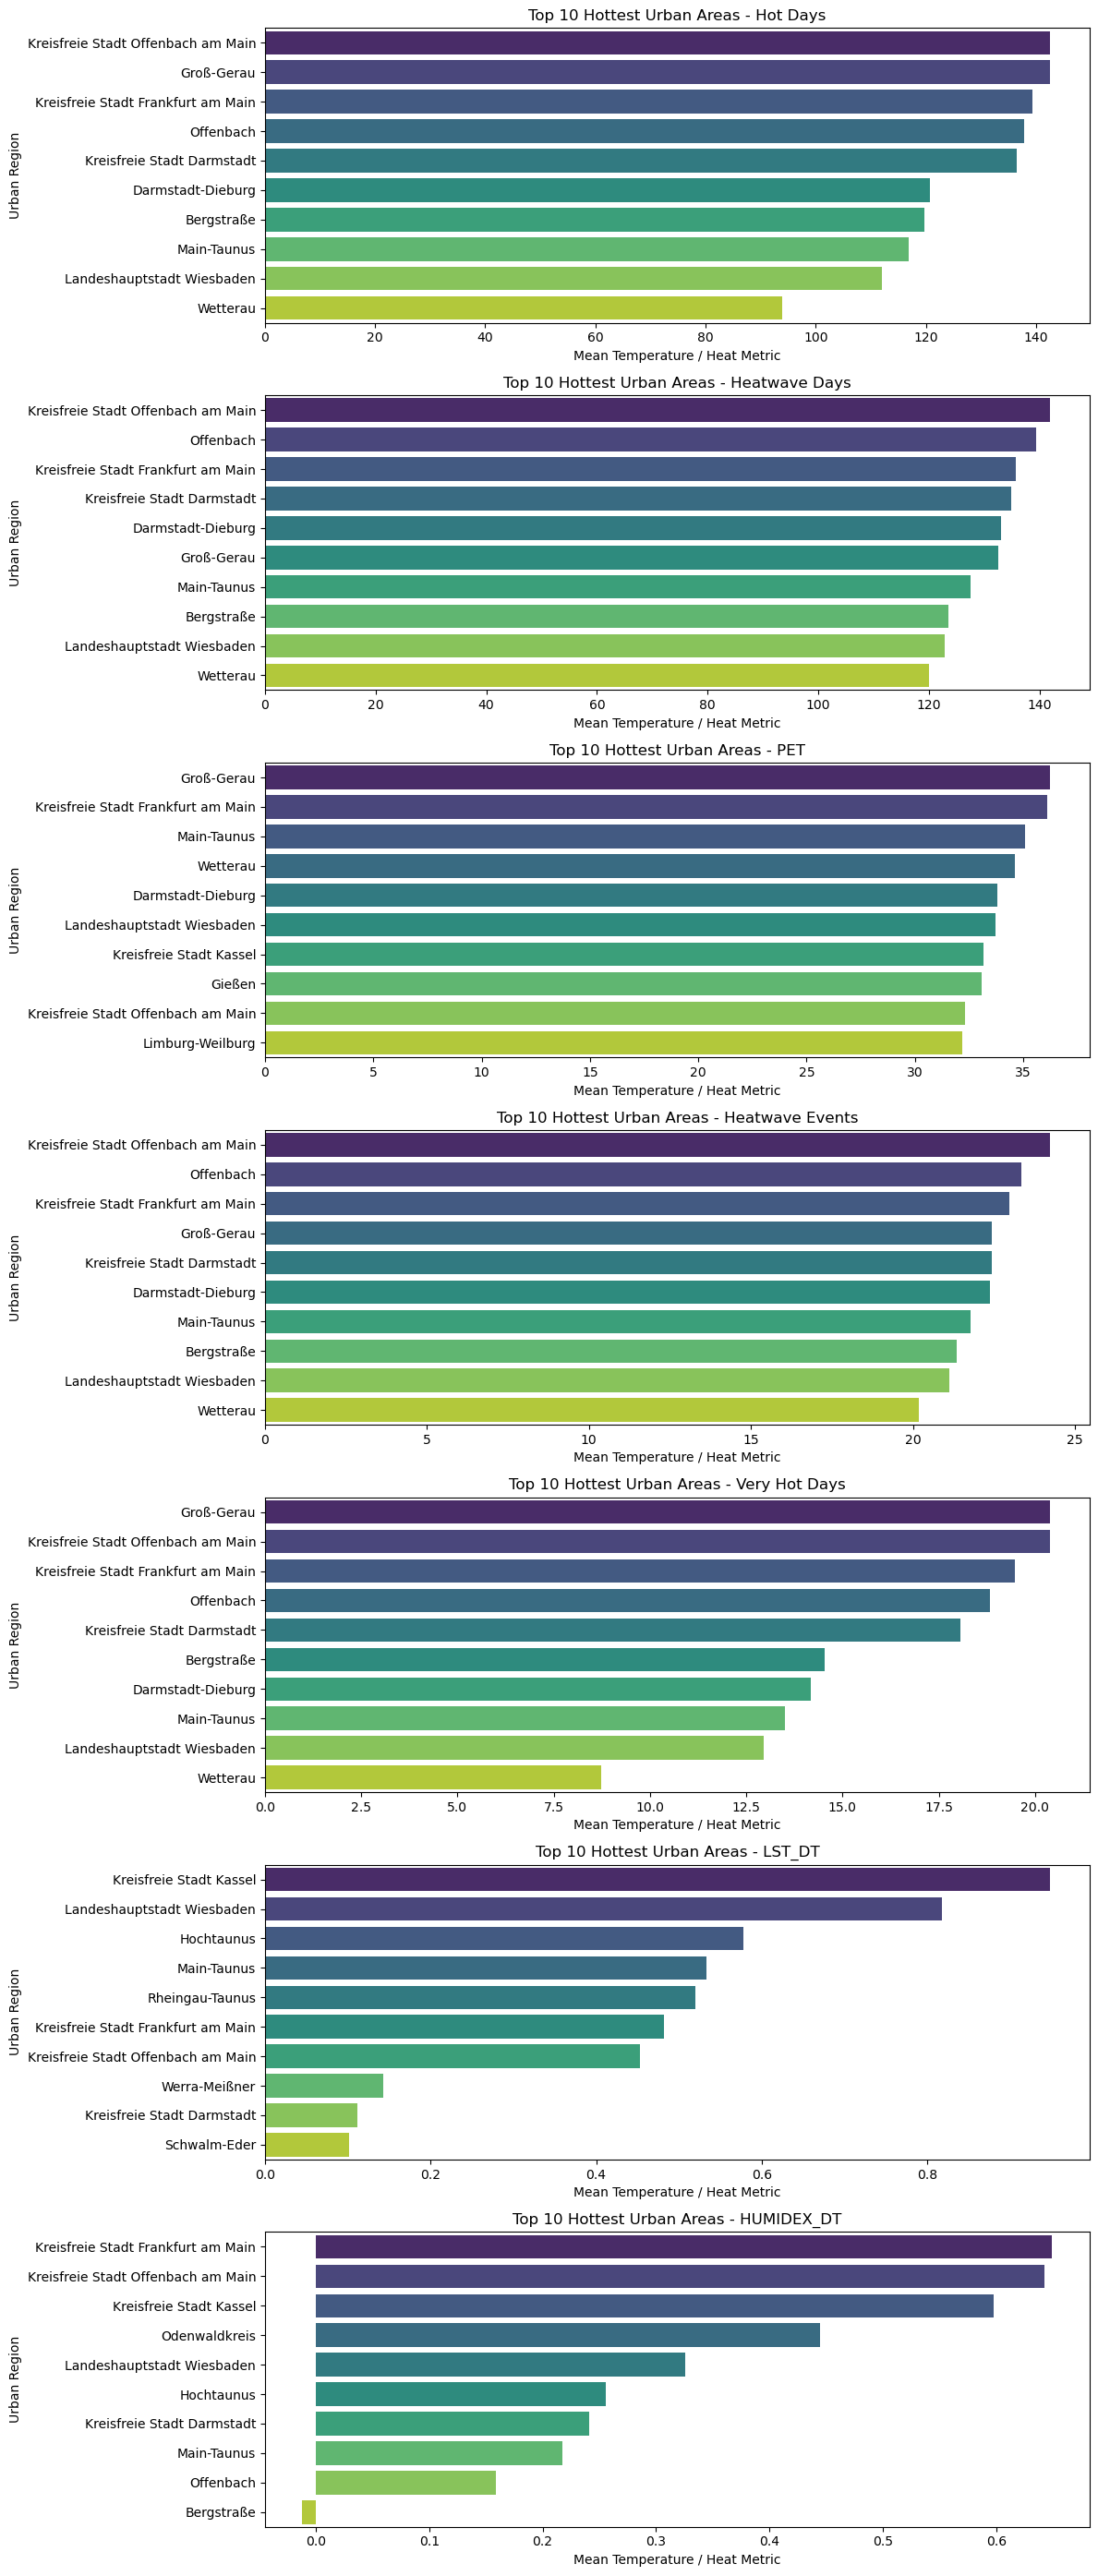

In [14]:
# Get unique variables
variables = df_zonal_stats["Variable"].unique()

# Create a separate plot per variable
fig, axes = plt.subplots(nrows=len(variables), figsize=(12, len(variables) * 4))

for ax, variable in zip(axes, variables):
    # Filter top 10 hottest regions for this variable
    top10 = df_zonal_stats[df_zonal_stats["Variable"] == variable].nlargest(10, "mean")

    # Create barplot
    sns.barplot(
        data=top10,
        x="mean",
        y="Region",
        ax=ax,
        palette="viridis"
    )

    # Formatting
    ax.set_xlabel("Mean Temperature / Heat Metric")
    ax.set_ylabel("Urban Region")
    ax.set_title(f"Top 10 Hottest Urban Areas - {variable}")

plt.tight_layout()
plt.show()


In [15]:
# Step 1: Rank each region within each variable
df_zonal_stats["rank"] = df_zonal_stats.groupby("Variable")["mean"].rank(ascending=False)

# Step 2: Compute overall ranking score per region
region_scores = df_zonal_stats.groupby("Region")["rank"].sum().reset_index()

# Step 3: Sort by the lowest total rank (since 1st place in ranking is hottest)
region_scores = region_scores.sort_values(by="rank", ascending=True)

# Step 4: Get top 10 hottest regions
top_10_hottest_regions = region_scores.head(10)

# Display results
print(top_10_hottest_regions)


                                Region  rank
9   Kreisfreie Stadt Frankfurt am Main  21.0
11  Kreisfreie Stadt Offenbach am Main  23.0
16                         Main-Taunus  45.0
13          Landeshauptstadt Wiesbaden  49.0
8           Kreisfreie Stadt Darmstadt  50.0
4                           Groß-Gerau  52.0
19                           Offenbach  58.0
1                    Darmstadt-Dieburg  59.0
0                           Bergstraße  70.0
10             Kreisfreie Stadt Kassel  79.0


In [16]:
# Step 1: Rank each region within each variable
df_zonal_stats["rank"] = df_zonal_stats.groupby("Variable")["max"].rank(ascending=False)

# Step 2: Compute overall ranking score per region
region_scores = df_zonal_stats.groupby("Region")["rank"].sum().reset_index()

# Step 3: Sort by the lowest total rank (since 1st place in ranking is hottest)
region_scores = region_scores.sort_values(by="rank", ascending=True)

# Step 4: Get top 10 hottest regions
top_10_hottest_regions = region_scores.head(10)

# Display results
print(top_10_hottest_regions)

                                Region  rank
9   Kreisfreie Stadt Frankfurt am Main  28.5
0                           Bergstraße  38.0
15                         Main-Kinzig  38.0
4                           Groß-Gerau  44.0
13          Landeshauptstadt Wiesbaden  49.0
1                    Darmstadt-Dieburg  54.0
11  Kreisfreie Stadt Offenbach am Main  56.5
19                           Offenbach  57.5
8           Kreisfreie Stadt Darmstadt  63.5
25                            Wetterau  76.0


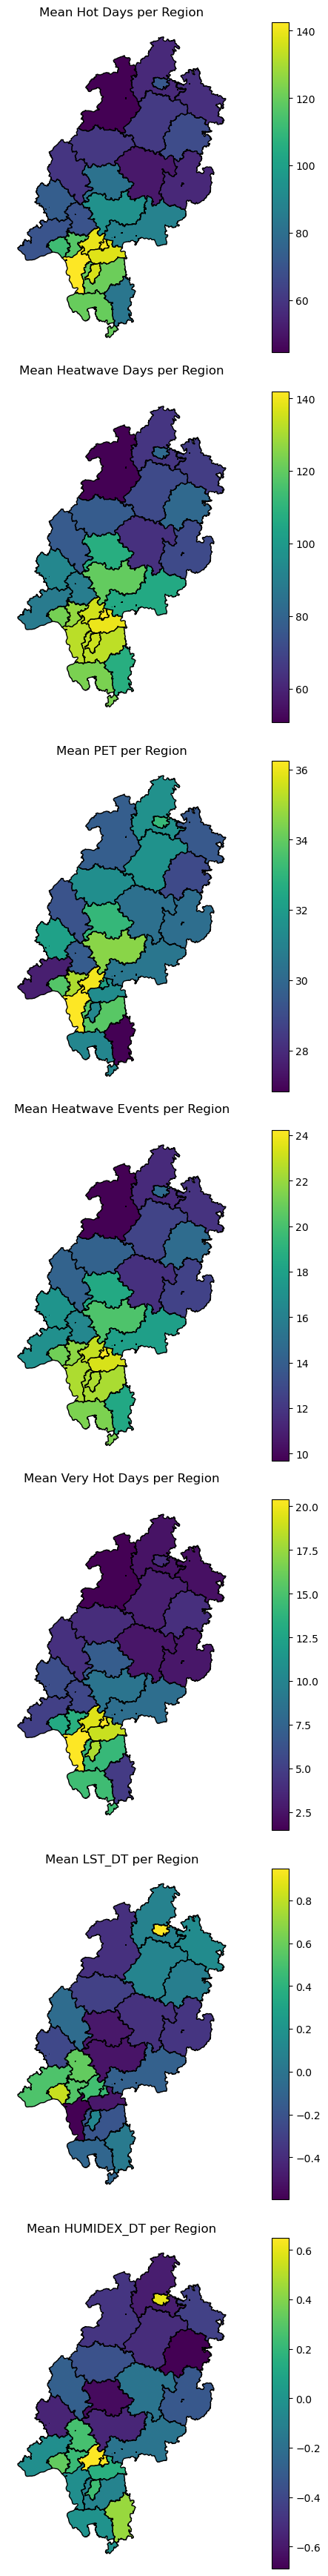

In [17]:
# Get unique variables
variables = gdf_zonal_stats["Variable"].unique()

# Create subplots (one row per variable)
fig, axes = plt.subplots(nrows=len(variables), figsize=(10, len(variables) * 5))

# Ensure axes is iterable (for single-variable case)
if len(variables) == 1:
    axes = [axes]

# Iterate through each variable and plot it on a map
for ax, variable in zip(axes, variables):
    data_subset = gdf_zonal_stats[gdf_zonal_stats["Variable"] == variable]

    # Convert to GeoDataFrame for spatial plotting
    gdf_variable = gpd.GeoDataFrame(data_subset, geometry="geometry", crs=roi_gdf.crs)

    # Plot
    gdf_variable.plot(column="mean", cmap="viridis", edgecolor="black", legend=True, ax=ax)

    ax.set_title(f"Mean {variable} per Region")
    ax.set_axis_off()  # Hide axis for better visualization

plt.tight_layout()
plt.show()


# 2. Hottest Region in Detail

In [ ]:
roi = gpd.read_file(path_roi)

# For only selected regions
# roi = roi[roi["gid"] == 113] #gid 302 = FFM 259 Kassel Stadt 150 Fulda 113 Darmstadt

# selected_gids = [250,94,93,249,16,15]  # FFM (302), Kassel Stadt (259), Fulda (150), Darmstadt (113)

# Filter ROI based on the selected GIDs
# roi = roi[roi["gid"].isin(selected_gids)]

print(roi)
roi.plot()

In [20]:
# Function to crop raster based on ROI and set pixels outside ROI to NaN
def crop_raster(raster_path, roi):
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, roi.geometry, crop=True, nodata=np.nan, filled=False)

        # Convert masked values to NaN while keeping valid 0s inside the ROI
        out_image = out_image.astype(float)  # Ensure float type for NaN assignment
        out_image[out_image.mask] = np.nan  # Apply NaN to masked areas

        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": np.nan  # Set nodata value to NaN in metadata
        })

    return out_image, out_meta

# Crop the raster files based on the ROI
lst_dt_cropped, lst_dt_meta = crop_raster(path_LST_DT, roi)
humidex_dt_cropped, humidex_dt_meta = crop_raster(path_HUMIDEX_DT, roi)
hot_day_cropped, hot_day_meta = crop_raster(path_hot_day, roi)
very_hot_day_cropped, very_hot_day_meta = crop_raster(path_very_hot_day, roi)
pet_cropped, pet_meta =  crop_raster(path_PET, roi)
pet_cropped[pet_cropped==9999] = np.nan
Ta_dt_mean_cropped, Ta_mean_meta = crop_raster(path_Ta_DT_mean, roi)
Ta_dt_90th_cropped, Ta_90th_meta = crop_raster(path_Ta_DT_90, roi)

heatwave_events, heatwave_events_meta = crop_raster(path_heatwave_events, roi)
heatwave_days, heatwave_days_meta = crop_raster(path_heatwave_days, roi)

hotspots, hotspots_meta = crop_raster(path_hotspots, roi)
coldspots, coldspots_meta = crop_raster(path_coldspots, roi)

print("Raster files have been successfully cropped based on the ROI.")

Raster files have been successfully cropped based on the ROI.


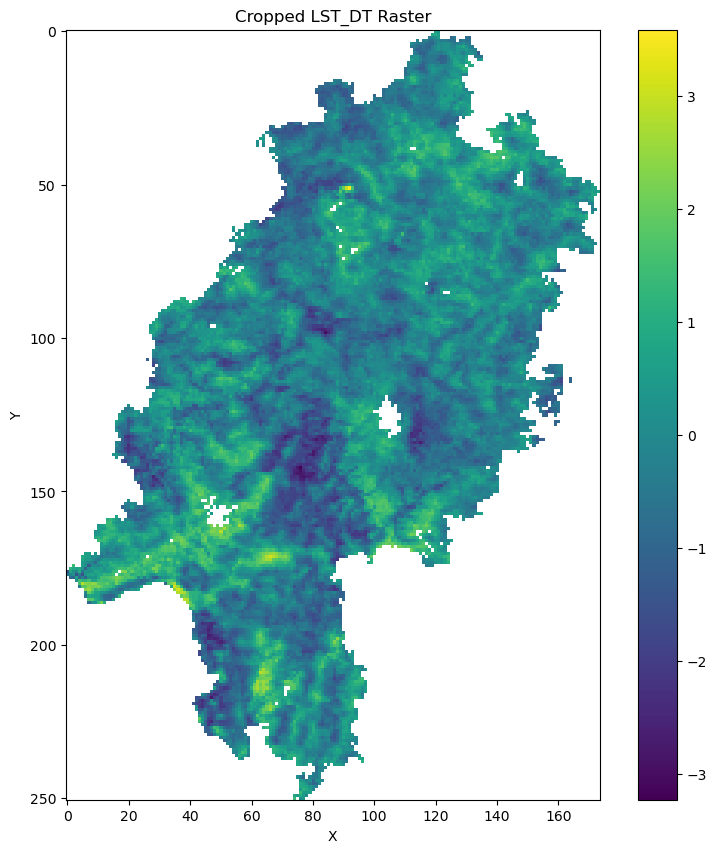

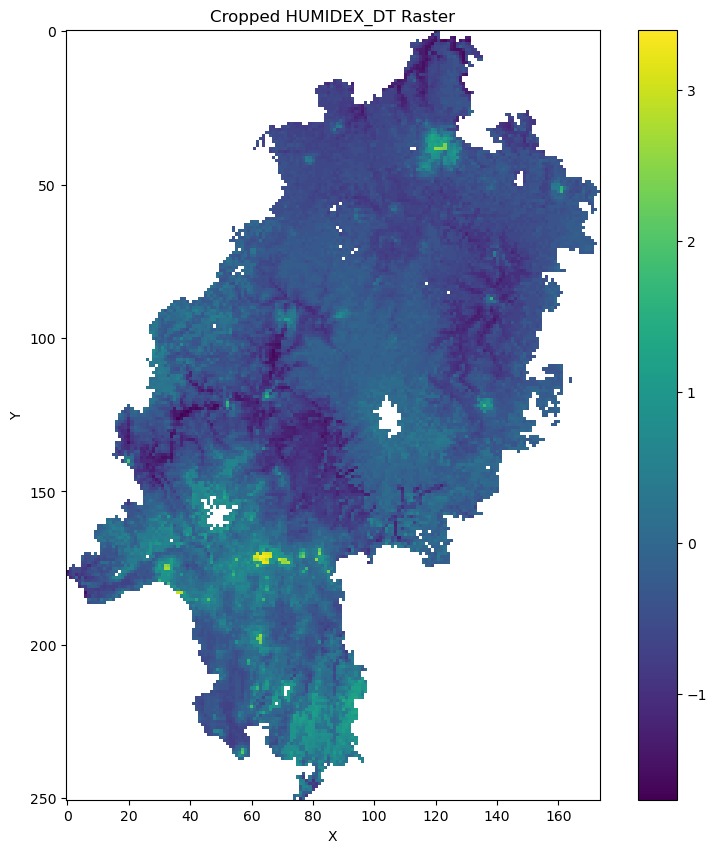

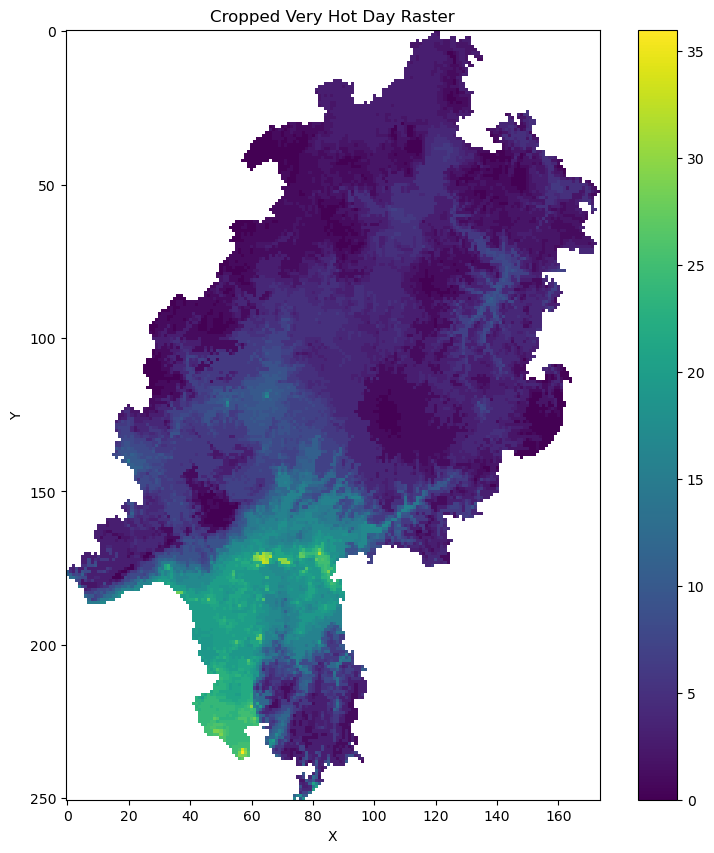

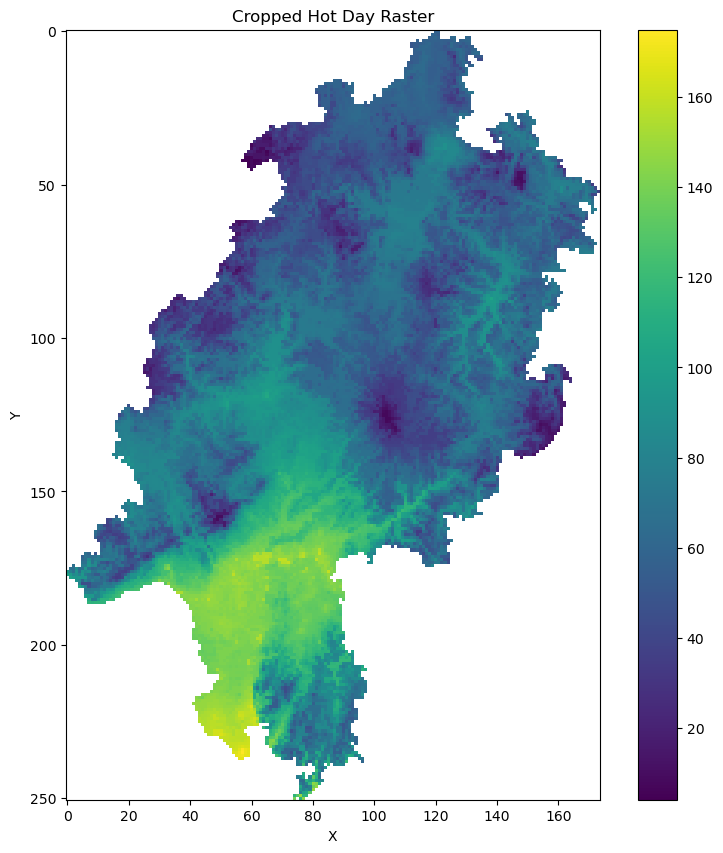

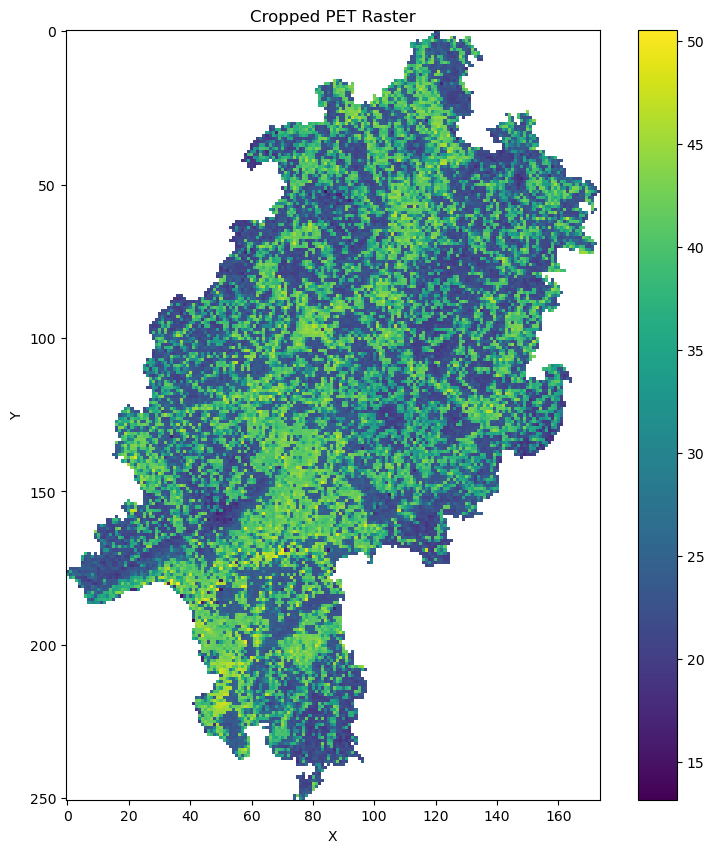

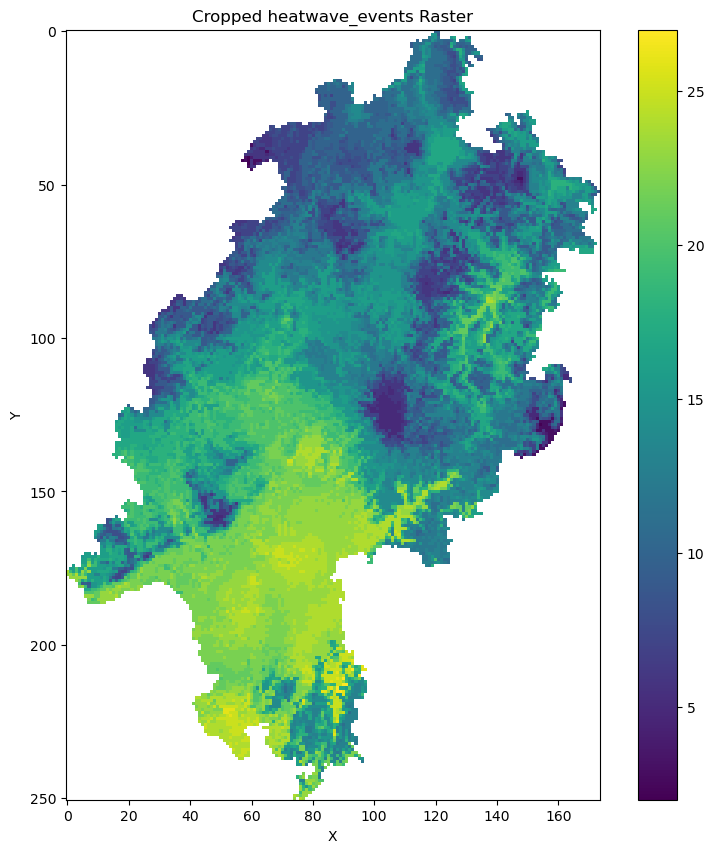

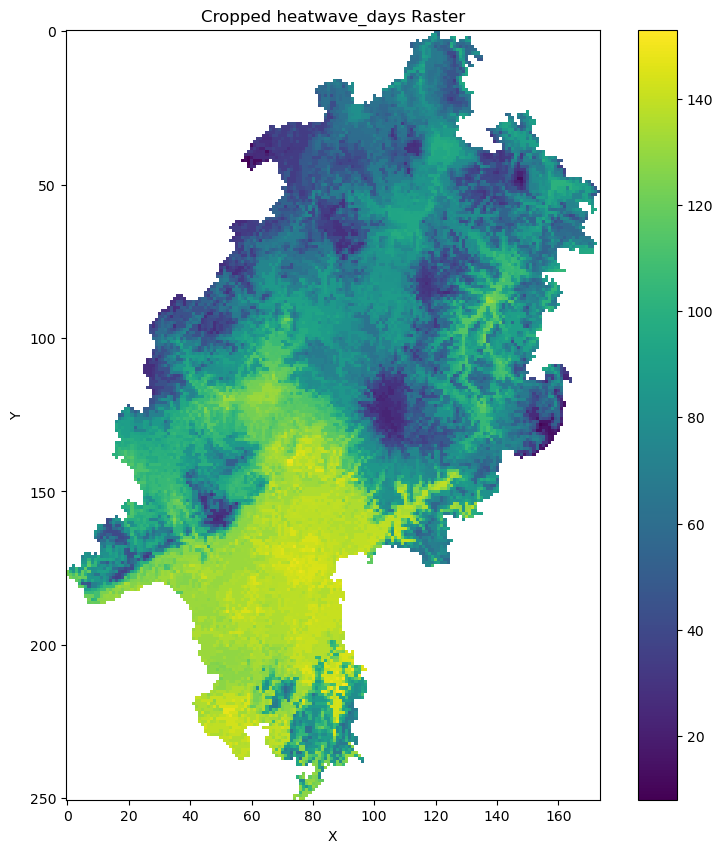

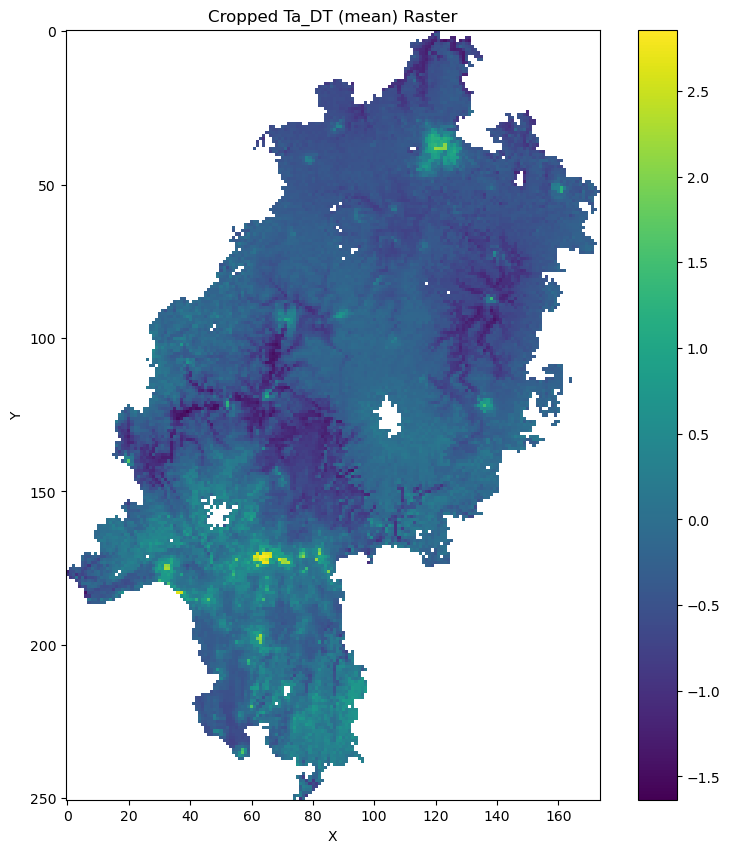

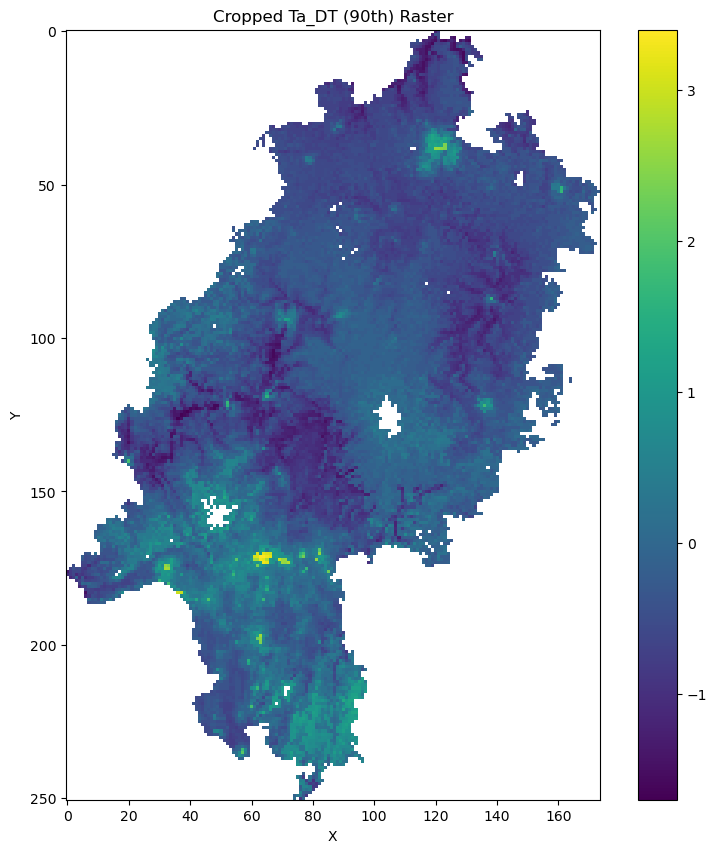

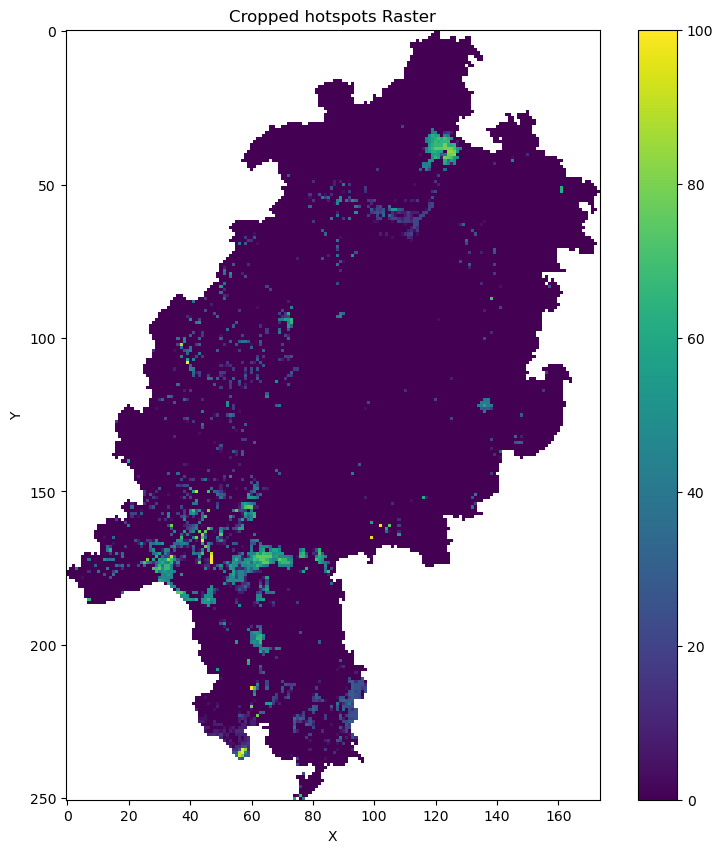

In [21]:
# Function to plot the cropped raster data
def plot_raster(raster_data, title):
    plt.figure(figsize=(10, 10))
    plt.imshow(raster_data[0], cmap='viridis')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

# Plot the cropped raster data
plot_raster(lst_dt_cropped, "Cropped LST_DT Raster")
plot_raster(humidex_dt_cropped, "Cropped HUMIDEX_DT Raster")
plot_raster(very_hot_day_cropped, "Cropped Very Hot Day Raster")
plot_raster(hot_day_cropped, "Cropped Hot Day Raster")
plot_raster(pet_cropped, "Cropped PET Raster")
plot_raster(heatwave_events, "Cropped heatwave_events Raster")
plot_raster(heatwave_days, "Cropped heatwave_days Raster")
plot_raster(Ta_dt_mean_cropped, "Cropped Ta_DT (mean) Raster")
plot_raster(Ta_dt_90th_cropped, "Cropped Ta_DT (90th) Raster")
plot_raster(hotspots, "Cropped hotspots Raster")
# plot_raster(coldspots, "Cropped coldspots Raster")

In [ ]:
def raster_to_dataframe(raster_data, transform, name):
    """Convert raster data to a DataFrame with x, y, and values."""
    height, width = raster_data.shape
    xs, ys, values = [], [], []

    for i in range(height):
        for j in range(width):
            value = raster_data[i, j]
            if not np.isnan(value):  # Exclude NaN values
                x, y = transform * (j, i)  # Convert to spatial coordinates
                xs.append(x)
                ys.append(y)
                values.append(value)

    return pd.DataFrame({"x": xs, "y": ys, name: values})

# Convert all rasters to DataFrames
df_lst_dt = raster_to_dataframe(lst_dt_cropped[0], lst_dt_meta['transform'], "LST_DT")
df_humidex_dt = raster_to_dataframe(humidex_dt_cropped[0],humidex_dt_meta['transform'], "HUMIDEX_DT")
df_vhd = raster_to_dataframe(very_hot_day_cropped[0],very_hot_day_meta['transform'], "Very_Hot_Day")
df_hd = raster_to_dataframe(hot_day_cropped[0],hot_day_meta['transform'], "Hot_Day")
df_pet = raster_to_dataframe(pet_cropped[0], pet_meta['transform'], "PET")
df_heatwave_events = raster_to_dataframe(heatwave_events[0], heatwave_events_meta['transform'], "heatwave events")
df_heatwave_days = raster_to_dataframe(heatwave_days[0], heatwave_days_meta['transform'], "heatwave days")
df_hotspots = raster_to_dataframe(hotspots[0], hotspots_meta['transform'], "hotspots")
df_Ta_mean = raster_to_dataframe(Ta_dt_mean_cropped[0], Ta_mean_meta['transform'], "Ta_DT (mean)")
df_Ta_90 = raster_to_dataframe(Ta_dt_90th_cropped[0], Ta_90th_meta['transform'], "Ta_DT (90th)")

# Merge all DataFrames on x, y
df_flat = (df_lst_dt.merge(df_humidex_dt, on=["x", "y"], how="inner")
                      .merge(df_vhd, on=["x", "y"], how="inner")
                      .merge(df_hd, on=["x", "y"], how="inner")
                      .merge(df_pet, on=["x", "y"], how="inner")
                        .merge(df_hotspots, on=["x", "y"], how="inner")
                      .merge(df_heatwave_events, on=["x", "y"], how="inner")
                      .merge(df_heatwave_days, on=["x", "y"], how="inner")
          .merge(df_Ta_mean, on=["x", "y"], how="inner")
          .merge(df_Ta_90, on=["x", "y"], how="inner"))

# Display summary of merged DataFrame
print(df_flat.info())
print(df_flat.head())


In [ ]:
df_flat.describe()

In [ ]:
df_flat["Hot_Day"].min()

In [32]:
# Define the brush selection for interactivity
temp_color_scale = alt.Scale(
    scheme="plasma",  # or 'reds', 'viridis', 'magma', etc.
    #domain=[110, 160]  # Adjust based on actual values
    domain=[11, 175]  # Adjust based on actual values
)

brush = alt.selection_interval()


# List of temperature-related variables
variables = ["Very_Hot_Day","Hot_Day","heatwave events","heatwave days","LST_DT", "HUMIDEX_DT", "PET"]

# Generate all pairwise scatter plots
scatter_plots = []
for x_var, y_var in itertools.combinations(variables, 2):
    scatter = alt.Chart(df_flat).mark_circle(opacity=0.8, size=30).encode(
        x=alt.X(f"{x_var}:Q", title=x_var.replace("_", " ")).scale(zero=False),
        y=alt.Y(f"{y_var}:Q", title=y_var.replace("_", " ")).scale(zero=False),
        #color=alt.Color(f"{y_var}:Q", scale=temp_color_scale, legend=alt.Legend(title=y_var.replace("_", " ")))
        color=alt.Color('Hot_Day:Q', scale=temp_color_scale, legend=alt.Legend(title=y_var.replace("_", " ")))
    ).add_params(brush).properties(
        width=250,
        height=250,
        title=f"{x_var.replace('_', ' ')} vs. {y_var.replace('_', ' ')}"
    )
    scatter_plots.append(scatter)

# Arrange scatter plots in a grid layout
scatter_grid = alt.vconcat(*[alt.hconcat(*scatter_plots[i:i+3]) for i in range(0, len(scatter_plots), 3)])

# Define x and y axis domains based on the full dataset
x_domain = [df_flat["x"].min(), df_flat["x"].max()]
y_domain = [df_flat["y"].min(), df_flat["y"].max()]

# Heatmap: Spatial distribution (x, y) with HUMIDEX color
heatmap = alt.Chart(df_flat).mark_square(size=400).encode(
    x=alt.X('x:Q', title="Longitude", scale=alt.Scale(domain=x_domain)),  
    y=alt.Y('y:Q', title="Latitude", scale=alt.Scale(domain=y_domain, reverse=False)),  
    color=alt.Color('Hot_Day:Q', scale=temp_color_scale, legend=alt.Legend(title="Number of Hot Days"))
).transform_filter(
    brush
).properties(
    width=500,
    height=500,
    title="Spatial Distribution of Very Hot Days"
)

# Histogram for temperature value distribution
hist = alt.Chart(df_flat).mark_bar(opacity=0.7).encode(
    x=alt.X('LST_DT:Q', bin=True, title="LST (°C)"),
    y=alt.Y('count()', title="Frequency"),
    color=alt.Color('LST_DT:Q', scale=alt.Scale(scheme="reds"), legend=alt.Legend(title="LST (°C)"))
).transform_filter(
    brush
).properties(
    width=400,
    height=300,
    title="LST Value Distribution"
)

# Final Layout: Scatter grid with Heatmap & Histogram
final_layout = scatter_grid | (heatmap | hist)

# Display the final visualization
final_layout

# final_layout.save('final_layout.png')

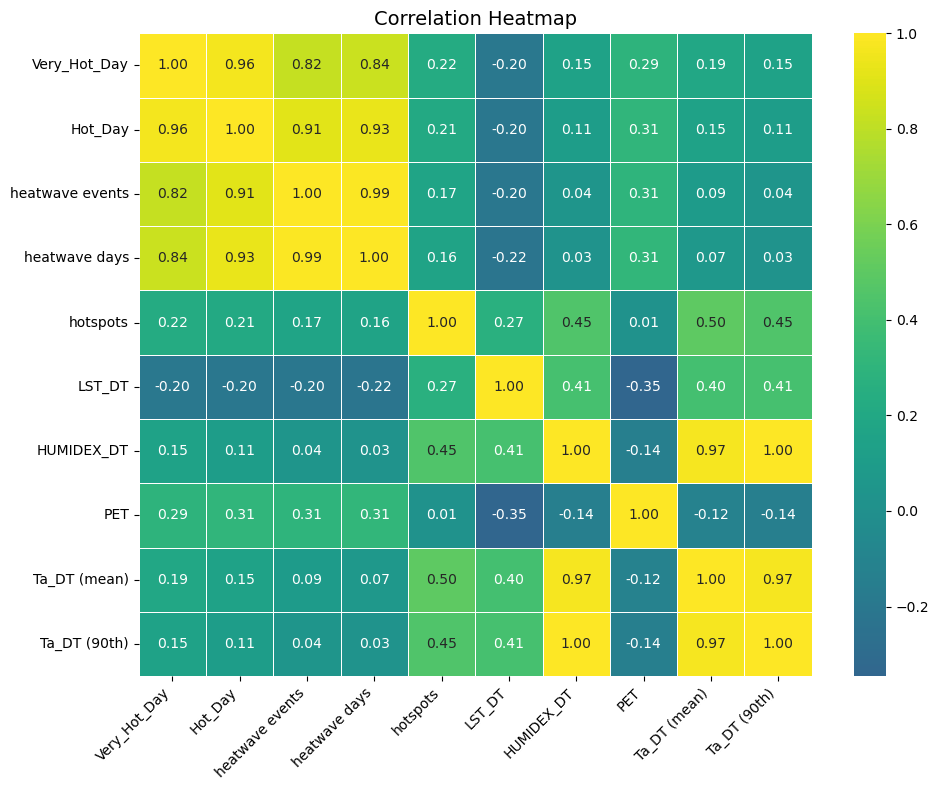

In [272]:
# Select only the relevant variables for correlation
corr_variables = [
    "Very_Hot_Day", "Hot_Day", "heatwave events", "heatwave days", 
    "hotspots", "LST_DT", "HUMIDEX_DT", "PET", "Ta_DT (mean)", "Ta_DT (90th)"
]

# Compute the correlation matrix
corr_matrix = df_flat[corr_variables].corr()

# Plot correlation heatmap with values
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,  # Display correlation values
    fmt=".2f",  # Format to 2 decimal places
    cmap="viridis",  # Color scheme
    center=0,  # Center around zero
    linewidths=0.5,  # Thin grid lines
    cbar=True  # Show color bar
)

# Titles and labels
plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

# Show the plot
plt.tight_layout()
plt.show()



### Top all based on mean

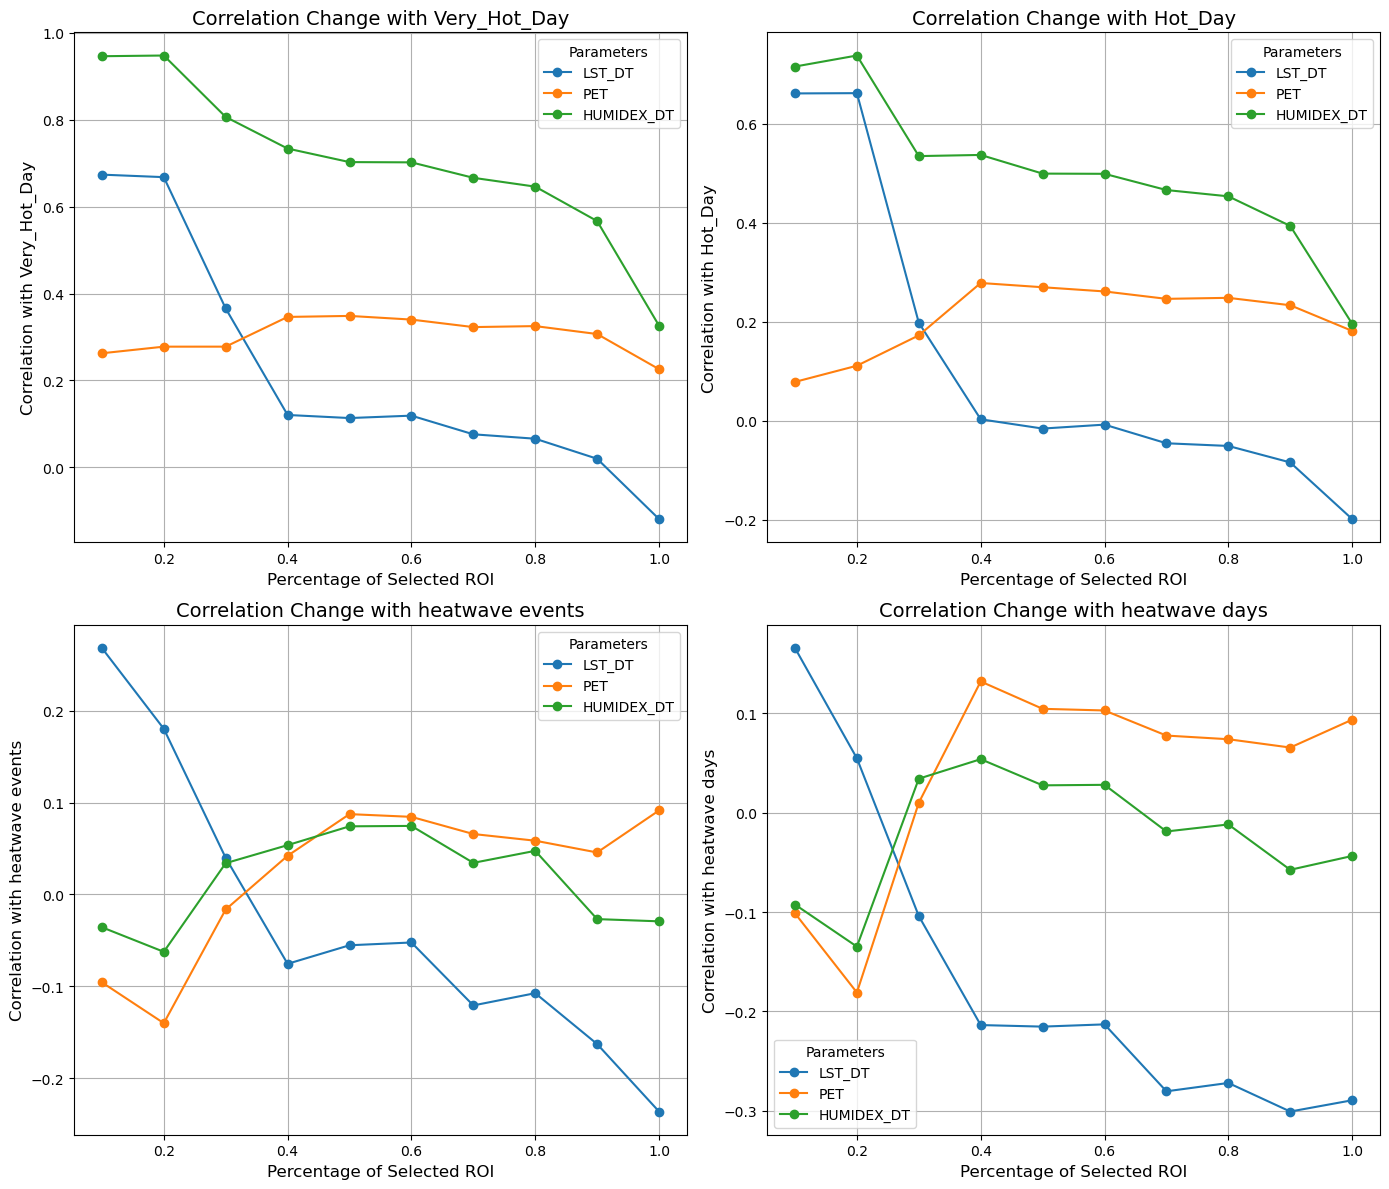

In [284]:
# Load ROI shapefile
roi = gpd.read_file(path_roi)

# Define the list of GIDs (selected regions)
selected_gids = list(top_10_hottest_regions["Region"].values)#[250, 94, 93, 249, 16, 15]  

# Create GeoDataFrame for df_flat (convert x, y to geometry)
geometry = [Point(xy) for xy in zip(df_flat["x"], df_flat["y"])]
df_flat_gdf = gpd.GeoDataFrame(df_flat, geometry=geometry, crs=roi.crs)

# Define target variables for correlation
target_variables = ["Very_Hot_Day", "Hot_Day", "heatwave events", "heatwave days"]

# Variables to check correlation with
correlation_parameters = ["LST_DT", "PET", "HUMIDEX_DT"]

# Percentage steps (0.1 to 1.0 in equal steps)
num_steps = len(selected_gids)
percentages = np.linspace(1/num_steps, 1.0, num_steps)

# Store results for all target variables
all_correlation_results = {}

for target in target_variables:
    correlation_results = []
    
    for i, p in enumerate(percentages):
        # Select first (i+1) GIDs
        current_gids = selected_gids[:i+1]

        # Filter ROI for selected GIDs
        roi_filtered = roi[roi["gid"].isin(current_gids)]

        # Spatial join: Select df_flat points inside the selected ROI
        df_filtered = df_flat_gdf[df_flat_gdf.geometry.within(roi_filtered.unary_union)]

        # Compute correlation matrix
        corr_matrix = df_filtered.drop(columns=["x", "y", "geometry"]).corr()

        # Extract correlations for the current target variable
        selected_corrs = corr_matrix.loc[target, correlation_parameters]

        # Store percentage and correlation values
        correlation_results.append({"percentage": p, **selected_corrs.to_dict()})

    # Convert results to DataFrame and store
    all_correlation_results[target] = pd.DataFrame(correlation_results)

# Plot the correlation changes for each target variable
fig, axes = plt.subplots(2, 2, figsize=(14, 12))  # 2x2 grid of plots
axes = axes.flatten()  # Flatten for easy iteration

for idx, target in enumerate(target_variables):
    ax = axes[idx]
    
    df_correlation = all_correlation_results[target]

    for param in correlation_parameters:
        ax.plot(df_correlation["percentage"], df_correlation[param], label=param, marker="o")

    # Labels and title
    ax.set_xlabel("Percentage of Selected ROI", fontsize=12)
    ax.set_ylabel(f"Correlation with {target}", fontsize=12)
    ax.set_title(f"Correlation Change with {target}", fontsize=14)
    ax.legend(title="Parameters", fontsize=10)
    ax.grid(True)

# Adjust layout and show the plots
plt.tight_layout()
plt.savefig('./heatextremes_correlation.svg')